In [94]:
# I want to do a simultaneous evaluation of the POIs and compute the correlation matrix
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations
import yaml


In [95]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [96]:
plot_dir = "Plots_sensitivity_study"
os.makedirs(plot_dir, exist_ok=True)


In [8]:
# Load PTH toys
variable = "PTH"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]
# poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0"]


pois_untrimmed_PTH = create_json_untrimmed_per_variable(variable, toyDir, poi_list)
pois_PTH = create_json_trimmed(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_PTH, poi_list, variable)

Trimming values:  -0.2869452894504838 3.609712239945316


In [9]:
# Load NJ toys
variable = "NJ"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed_per_variable(variable, toyDir, poi_list_NJ)
pois_NJ = create_json_trimmed(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_untrimmed_NJ, poi_list_NJ, variable)

Trimming values:  -2.2625865862319543 3.9007698902838905


In [10]:
# Load rapidity toys
variable = "rapidity"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_rapidity = ["r_YH_0p0_0p15", "r_YH_0p15_0p3", "r_YH_0p3_0p6", "r_YH_0p6_0p9", "r_YH_0p9_2p5"]

pois_untrimmed_rapidity = create_json_untrimmed_per_variable(variable, toyDir, poi_list_rapidity)
pois_rapidity = create_json_trimmed(variable, toyDir, pois_untrimmed_rapidity, poi_list_rapidity, subfolder_=f"SL_{variable}")

Trimming values:  -0.08348520809314364 4.386301128082355


In [ ]:
# Load PTJ0 toys
variable = "PTJ0"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_PTJ0 = ["r_PTJ0_0p0_30p0", "r_PTJ0_30p0_75p0", "r_PTJ0_75p0_120p0", "r_PTJ0_120p0_200p0", "r_PTJ0_200p0_10000p0"]

pois_untrimmed_PTJ0 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_PTJ0)
pois_PTJ0 = create_json_trimmed(variable, toyDir, pois_untrimmed_PTJ0, poi_list_PTJ0, subfolder_=f"SL_{variable}")

Trimming values:  -1.369093104556015 5.00149407058432


In [12]:
# Load DPhiJ0J1 toys
variable = "DPhiJ0J1"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_DPhiJ0J1 = ["r_DPhiJ0J1_m3p1416_m2p0944", "r_DPhiJ0J1_m2p0944_m1p0472", "r_DPhiJ0J1_m1p0472_0p0", "r_DPhiJ0J1_0p0_1p0472", "r_DPhiJ0J1_1p0472_2p0944", "r_DPhiJ0J1_2p0944_3p1416"]

pois_untrimmed_DPhiJ0J1 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_DPhiJ0J1)
pois_DPhiJ0J1 = create_json_trimmed(variable, toyDir, pois_untrimmed_DPhiJ0J1, poi_list_DPhiJ0J1, subfolder_=f"SL_{variable}")

Trimming values:  -2.8522339445867724 8.189748055411972


In [ ]:
# Drop first bin of PTJ0 (as it is identical to the first bin of NJ)
pois_PTJ0 = {key: pois_PTJ0[key] for key in list(pois_PTJ0.keys())[1:]}

{'r_PTJ0_30p0_75p0': [1.5155097246170044,
  1.2359166145324707,
  1.0467040538787842,
  0.7083784937858582,
  1.8105688095092773,
  1.378440022468567,
  0.7213009595870972,
  1.4403700828552246,
  1.579984188079834,
  0.9158689379692078,
  1.575142741203308,
  1.5378365516662598,
  1.6970696449279785,
  0.9437363147735596,
  0.7721920609474182,
  -999.0,
  0.9142508506774902,
  1.2226881980895996,
  0.6477359533309937,
  1.9297953844070435,
  1.0330181121826172,
  -999.0,
  0.7051544189453125,
  -999.0,
  1.0524787902832031,
  1.4135799407958984,
  0.419175386428833,
  1.4916436672210693,
  0.5745911598205566,
  1.6237961053848267,
  0.5087268948554993,
  1.9424896240234375,
  1.0075467824935913,
  0.6850626468658447,
  -999.0,
  0.9224227070808411,
  -999.0,
  0.9165906310081482,
  1.1708109378814697,
  1.6920807361602783,
  2.134856939315796,
  0.6579363942146301,
  1.1835033893585205,
  1.7349966764450073,
  1.2978156805038452,
  -999.0,
  0.9388636946678162,
  1.4337587356567383,
 

In [64]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
df_PTJ0 = pd.DataFrame(pois_PTJ0)
df_DPhiJ0J1 = pd.DataFrame(pois_DPhiJ0J1)
df_rapidity = pd.DataFrame(pois_rapidity)

In [65]:
df_PTH_untrimmed = pd.DataFrame(pois_untrimmed_PTH)
df_NJ_untrimmed = pd.DataFrame(pois_untrimmed_NJ)
df_PTJ0_untrimmed = pd.DataFrame(pois_untrimmed_PTJ0)
df_DPhiJ0J1_untrimmed = pd.DataFrame(pois_untrimmed_DPhiJ0J1)
df_rapidity_untrimmed = pd.DataFrame(pois_untrimmed_rapidity)
mask_pth_untrimmed = (df_PTH_untrimmed != -999).all(axis=1)
mask_nj_untrimmed = (df_NJ_untrimmed != -999).all(axis=1)
mask_PTJ0_untrimmed = (df_PTJ0_untrimmed != -999).all(axis=1)
mask_DPhiJ0J1_untrimmed = (df_DPhiJ0J1_untrimmed != -999).all(axis=1)
mask_rapidity_untrimmed = (df_rapidity_untrimmed != -999).all(axis=1)
valid_rows_untrimmed = mask_pth_untrimmed & mask_nj_untrimmed & mask_PTJ0_untrimmed & mask_DPhiJ0J1_untrimmed & mask_rapidity_untrimmed
df_PTH_clean_untrimmed = df_PTH_untrimmed[valid_rows_untrimmed]
df_NJ_clean_untrimmed = df_NJ_untrimmed[valid_rows_untrimmed]
df_PTJ0_clean_untrimmed = df_PTJ0_untrimmed[valid_rows_untrimmed]
df_DPhiJ0J1_clean_untrimmed = df_DPhiJ0J1_untrimmed[valid_rows_untrimmed]
df_rapidity_clean_untrimmed = df_rapidity_untrimmed[valid_rows_untrimmed]

/tmp/ipykernel_1229278/2638630945.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_PTJ0_clean_untrimmed = df_PTJ0_untrimmed[valid_rows_untrimmed]


In [91]:

# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# # Mask for df_PTH (True = valid, False = -999)
mask_pth = (df_PTH != -999).all(axis=1) 

# # Mask for df_NJ (True = valid, False = -999)
# mask_nj = (df_NJ != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
# mask_ptj0 = (df_PTJ0 != -999).all(axis=1)

# # # Mask for df_DPhiJ0J1 (True = valid, False = -999)
# mask_DPhiJ0J1 = (df_DPhiJ0J1 != -999).all(axis=1)

# # Mask for df_rapidity (True = valid, False = -999)
# mask_rapidity = (df_rapidity != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1 & mask_rapidity
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1
valid_rows = mask_pth
# valid_rows = mask_pth & mask_nj & mask_rapidity & mask_ptj0

# print(mask_pth.sum())
# print(mask_nj.sum())
# print(mask_rapidity.sum())
# print(mask_ptj0.sum())
# print(mask_DPhiJ0J1.sum())
# valid_rows = mask_pth & mask_nj & mask_rapidity

# --- Step 2: Filter DataFrames ---
df_PTH_clean = df_PTH[valid_rows]
df_NJ_clean = df_NJ[valid_rows]
df_PTJ0_clean = df_PTJ0[valid_rows]
df_DPhiJ0J1_clean = df_DPhiJ0J1[valid_rows]
# df_rapidity_clean = df_rapidity[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)
df_combined = pd.concat([df_PTH_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_PTJ0_clean, df_NJ_clean, df_DPhiJ0J1_clean], axis=1)


# Calculate full correlation matrix
# mask = df_combined["r_PTH_45p0_80p0"] > 2
# corr_matrix = df_combined[mask].corr()
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

df_combined

/tmp/ipykernel_1229278/1809263602.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_PTJ0_clean = df_PTJ0[valid_rows]


,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0
0,0.932272,1.294229,1.831626,1.435926,0.407468,2.072674,0.335692,-0.013463
1,0.791452,1.546120,1.965186,1.032743,0.880023,1.251404,0.667603,0.334226
2,0.897806,1.634806,1.053617,0.666152,0.265114,1.388253,0.269386,-0.225546
4,0.525900,0.933291,2.880022,0.989266,1.000431,1.192318,0.675010,-0.230720
5,0.989262,0.865907,0.996478,1.194350,0.040177,1.760615,0.482089,-0.050893
...,...,...,...,...,...,...,...,...
4994,0.967378,0.757512,2.048878,0.563330,0.764181,1.331676,-0.090880,0.408232
4995,1.187938,0.794234,1.305576,0.899539,1.103027,1.380097,0.656971,0.118064
4996,1.806397,0.881027,1.576357,1.329880,0.276027,1.621247,0.999583,-0.234896
4998,0.228864,0.997710,2.924754,1.415035,0.513213,1.334241,0.002757,0.460264


In [67]:
# mask = ~mask
# print((df_PTH_clean["r_PTH_45p0_80p0"] < 2).sum())

plt.figure(figsize=(12, 10))
plt.scatter(x=df_combined["r_YH_0p0_0p15"], y=df_combined["r_YH_0p3_0p6"])
# plt.xlim(0.995,1.005)
# plt.ylim(0.98,1.02)

# plt.xlabel(translation["r_PTH_200p0_350p0"])
# plt.ylabel(translation["r_PTH_45p0_80p0"])
# plt.show()
mask = (df_combined["r_YH_0p0_0p15"] > 0.5) & (df_combined["r_YH_0p0_0p15"] < 2.0) & (df_combined["r_YH_0p3_0p6"] > 0.5) & (df_combined["r_YH_0p3_0p6"] < 1.5)

print(mask.sum())

print(df_combined["r_YH_0p0_0p15"].corr(df_combined["r_YH_0p3_0p6"]))
print(df_combined[mask]["r_YH_0p0_0p15"].corr(df_combined[mask]["r_YH_0p3_0p6"]))
# print(df_PTH_clean["r_PTH_120p0_200p0"].corr(df_PTH_clean["r_PTH_15p0_30p0"]))

KeyError: 'r_YH_0p0_0p15'

<Figure size 1200x1000 with 0 Axes>

In [92]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

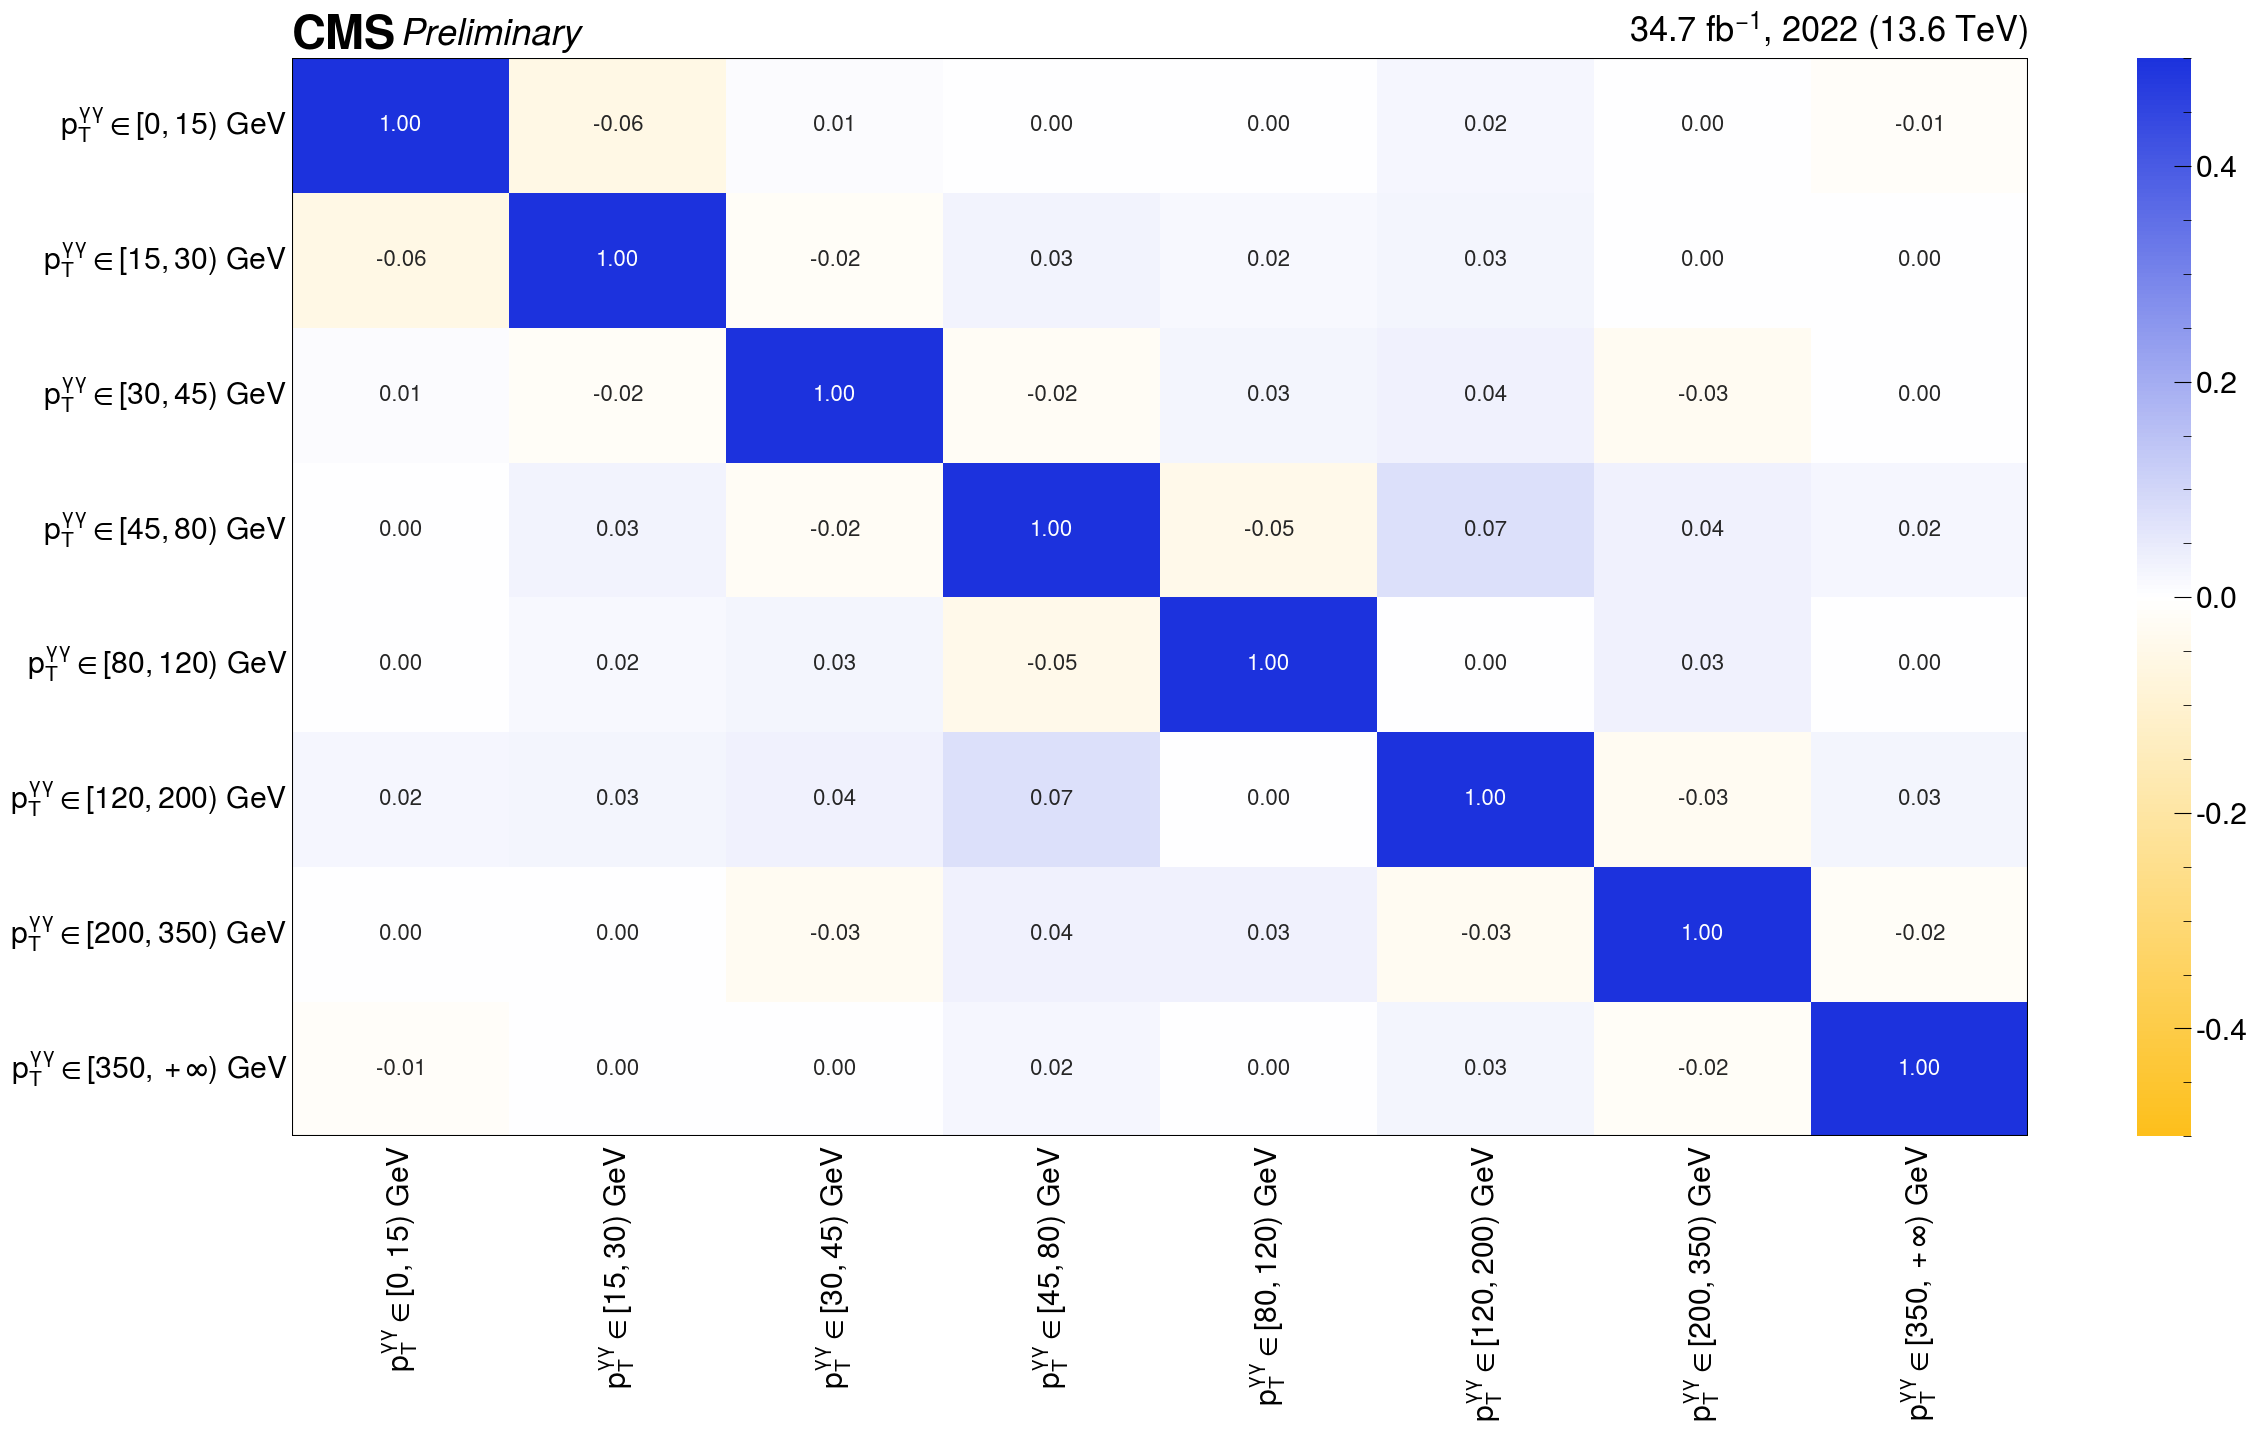

In [93]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix_translated = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=True, lumi=34.7, com=13.6, year=2022)
ax = sns.heatmap(modified_corr_matrix_translated, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix_translated.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 16, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs.png"), bbox_inches='tight')

# plt.close()


In [78]:
# Convert DataFrame to list of dictionaries
modified_corr_matrix_dict = modified_corr_matrix.to_dict(orient="records")

# Write to YAML file
with open("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/output.yaml", "w", encoding="utf-8") as f:
    yaml.dump(modified_corr_matrix_dict, f, sort_keys=False, allow_unicode=True)

In [79]:
# Load YAML file
with open("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/output.yaml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
df = df.set_index(df.columns)  # Set the first column as index

In [53]:
# Try applying the third moments 

def calc_abc_dict(pois):
    # First, calculate the third moments for each POI
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in list(pois.keys())])
    abc_dict = {}
    for i, current_poi in enumerate(pois.keys()):
        # print(i, current_poi)
        r = np.array(pois[current_poi])
        r = r[r > -998.0]
        m_one = np.mean(r)
        m_two = cov_matrix[i][i]
        m_three = np.mean((r - m_one)**3)
        
        c_i = -np.sign(m_three) * np.sqrt(2 * m_two) * np.cos(((4* np.pi) / 3) + ((1/3) * np.arctan(np.sqrt((8 * (m_two**3 / m_three**2)) - 1))))
        b_i = np.sqrt(m_two - 2*(c_i**2))
        a_i = m_one - c_i
        abc_dict[current_poi] = (a_i, b_i, c_i)
    return abc_dict
        

In [54]:
def calc_SL_rho(pois, abc_dict_):
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in pois.keys()])
    poi_names = list(pois.keys())
    rho = []
    for i, current_poi in enumerate(pois.keys()):
        a_i, b_i, c_i = abc_dict_[current_poi]
        rho_i = []
        for j, other_poi in enumerate(pois.keys()):
            a_j, b_j, c_j = abc_dict_[other_poi]
            m_two_ij = cov_matrix[i][j]
            
            rho_ij = (1/(4*c_i*c_j)) * (np.sqrt((b_i**2 * b_j**2) + 8*(c_i*c_j*m_two_ij)) - (b_i * b_j))
            rho_i.append(rho_ij)
        rho.append(rho_i)
        
    rho_df = pd.DataFrame(rho, index=poi_names, columns=poi_names)
    return rho_df


In [55]:
# Extend the pois to multplie variables
# combined_pois = {}
# for current_poi in poi_list:
#     combined_pois[current_poi] = pois_PTH[current_poi]
# for current_poi in poi_list_NJ:
#     combined_pois[current_poi] = pois_NJ[current_poi]

# combined_pois.keys()

combined_pois = df_combined.to_dict(orient='list')

In [56]:
abc_dict = calc_abc_dict(combined_pois)
corr_matrix = calc_SL_rho(combined_pois, abc_dict)

In [57]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 17, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.png"), bbox_inches='tight')
plt.show()

In [58]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [59]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
import numpy as np
t_values = np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))
np.fill_diagonal(t_values.values, 0)
sigma = t_values.max().max()

In [60]:
sigma